In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("dreamtensor/gaming-addiction-and-mental-health-analysis")

print("Path to dataset files:", path)

C:\Users\Admin\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\Admin\.cache\kagglehub\datasets\dreamtensor\gaming-addiction-and-mental-health-analysis\versions\1


In [4]:
import os

# 1. Dekhte hain ki download hue folder mein kaunsi files hain
files = os.listdir(path)
print("Folder mein yeh files hain:", files)

# 2. Agar .csv file hai, toh use DataFrame mein load karein
# Maan lete hain file ka naam 'gaming_addiction.csv' ya aisa hi kuch hoga
csv_file = [f for f in files if f.endswith('.csv')][0]
file_path = os.path.join(path, csv_file)

df = pd.read_csv(file_path)

# 3. DataFrame ka ek chhota sa preview dekhne ke liye
df.head(20)

Folder mein yeh files hain: ['gaming_addiction.csv']


,user_id,age,gender,country,occupation,income_level,years_gaming,preferred_genre,platform,device_type,...,absenteeism_days,internet_speed_mbps,screen_time_total_hours,behavioral_cluster,addiction_score,addiction_binary,addiction_severity,burnout_probability,mental_health_risk_score,churn_probability
0,USR000001,21,Male,India,Employed,Middle,9,Sandbox,PC,Laptop,...,7,39.9,5.4,Casual Enjoyer,27.61,0,Mild,1.000,0.920,1.000
1,USR000002,25,Male,India,Employed,Lower-Middle,13,RPG,Mobile,Mixed,...,6,71.5,13.4,Streamer/Creator,55.51,1,Moderate,1.000,0.515,0.813
2,USR000003,26,Male,Brazil,Employed,Middle,14,RPG,PC+Mobile,High-end PC,...,7,119.4,12.3,Streamer/Creator,45.85,0,Moderate,1.000,0.720,0.947
3,USR000004,22,Male,South Korea,Employed,Upper-Middle,10,Strategy,PC+Mobile,Mobile,...,8,136.5,6.9,Toxic Competitor,39.87,0,Mild,1.000,0.520,0.660
4,USR000005,17,Female,India,Student,Middle,5,Strategy,PC,Laptop,...,6,78.8,9.3,Competitive Grinder,46.97,0,Moderate,1.000,0.585,0.867
5,USR000006,13,Male,USA,Freelancer,Middle,1,Horror,PC,Mobile,...,3,93.8,3.7,Casual Enjoyer,17.26,0,NaN,0.320,0.400,0.150
6,USR000007,27,Male,UK,Unemployed,Lower-Middle,15,RPG,Console,Console,...,12,5.0,10.0,Toxic Competitor,34.82,0,Mild,1.000,0.550,0.879
7,USR000008,18,Non-binary,Canada,Student,Middle,6,MOBA,PC,Mixed,...,5,97.1,4.7,Casual Enjoyer,22.66,0,Mild,1.000,0.490,0.825
8,USR000009,16,Female,USA,Student,High,1,Sports,Mobile,Mixed,...,5,81.9,11.0,Toxic Competitor,35.08,0,Mild,1.000,0.400,0.928
9,USR000010,30,Female,Brazil,Freelancer,Middle,18,Strategy,Console,Mid-range PC,...,3,22.2,7.5,Competitive Grinder,46.24,0,Moderate,1.000,0.290,0.756


In [5]:
# Sirf important columns ki list
imp_columns = [
    'age', 'gender', 'country', 'preferred_genre', 
    'screen_time_total_hours', 'behavioral_cluster', 
    'addiction_score', 'addiction_severity', 
    'mental_health_risk_score', 'burnout_probability', 'absenteeism_days'
]

# Chhota DataFrame banana
df = df[imp_columns]

# Preview dekhne ke liye
df.head()

,age,gender,country,preferred_genre,screen_time_total_hours,behavioral_cluster,addiction_score,addiction_severity,mental_health_risk_score,burnout_probability,absenteeism_days
0,21,Male,India,Sandbox,5.4,Casual Enjoyer,27.61,Mild,0.920,1.0,7
1,25,Male,India,RPG,13.4,Streamer/Creator,55.51,Moderate,0.515,1.0,6
2,26,Male,Brazil,RPG,12.3,Streamer/Creator,45.85,Moderate,0.720,1.0,7
3,22,Male,South Korea,Strategy,6.9,Toxic Competitor,39.87,Mild,0.520,1.0,8
4,17,Female,India,Strategy,9.3,Competitive Grinder,46.97,Moderate,0.585,1.0,6


In [6]:
df.describe()

,age,screen_time_total_hours,addiction_score,mental_health_risk_score,burnout_probability,absenteeism_days
count,250.000000,250.000000,250.00000,250.000000,250.000000,250.00000
mean,22.160000,8.239600,38.74448,0.509640,0.996856,5.52400
std,5.455037,2.894558,11.74977,0.140448,0.043240,3.14212
min,13.000000,1.200000,12.28000,0.120000,0.320000,0.00000
25%,18.000000,6.200000,29.88250,0.406250,1.000000,3.00000
50%,22.000000,8.200000,39.87500,0.515000,1.000000,6.00000
75%,27.000000,10.500000,47.11000,0.600000,1.000000,8.00000
max,40.000000,15.100000,68.00000,0.920000,1.000000,14.00000


In [7]:
df.shape

(250, 11)

In [8]:
df.head()

,age,gender,country,preferred_genre,screen_time_total_hours,behavioral_cluster,addiction_score,addiction_severity,mental_health_risk_score,burnout_probability,absenteeism_days
0,21,Male,India,Sandbox,5.4,Casual Enjoyer,27.61,Mild,0.920,1.0,7
1,25,Male,India,RPG,13.4,Streamer/Creator,55.51,Moderate,0.515,1.0,6
2,26,Male,Brazil,RPG,12.3,Streamer/Creator,45.85,Moderate,0.720,1.0,7
3,22,Male,South Korea,Strategy,6.9,Toxic Competitor,39.87,Mild,0.520,1.0,8
4,17,Female,India,Strategy,9.3,Competitive Grinder,46.97,Moderate,0.585,1.0,6


In [9]:
print(df.value_counts(df["gender"]))

gender
Male                 158
Female                66
Non-binary            18
Prefer not to say      8
Name: count, dtype: int64
preferred_genre
MMORPG           39
Sandbox          29
Casual           29
Strategy         27
Battle Royale    26
RPG              23
MOBA             23
FPS              21
Horror           17
Sports           16
Name: count, dtype: int64


In [10]:
print(df.value_counts(df["preferred_genre"]))

preferred_genre
MMORPG           39
Sandbox          29
Casual           29
Strategy         27
Battle Royale    26
RPG              23
MOBA             23
FPS              21
Horror           17
Sports           16
Name: count, dtype: int64


In [11]:
print(df.value_counts(df["behavioral_cluster"]))

behavioral_cluster
Casual Enjoyer         43
Streamer/Creator       39
Social Gamer           39
Escape Seeker          37
Toxic Competitor       32
Competitive Grinder    30
Binge Player           30
Name: count, dtype: int64


In [12]:
print(df.value_counts(df["addiction_severity"]))

addiction_severity
Moderate    117
Mild        112
Severe        5
Name: count, dtype: int64


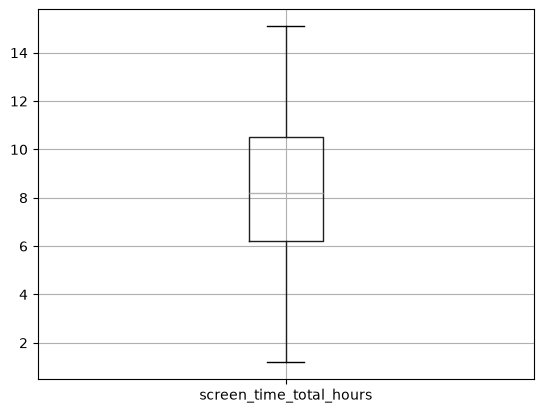

In [17]:
df.boxplot(
    column = "screen_time_total_hours"
)

plt.show()

In [21]:
df["age"].corr(df["screen_time_total_hours"])
# No good correlation

np.float64(-0.03992786489821578)

In [22]:
df.corr(numeric_only=True)

,age,screen_time_total_hours,addiction_score,mental_health_risk_score,burnout_probability,absenteeism_days
age,1.000000,-0.039928,-0.018404,-0.051767,0.103822,0.048510
screen_time_total_hours,-0.039928,1.000000,0.815875,0.168166,0.108556,0.442366
addiction_score,-0.018404,0.815875,1.000000,0.151173,0.128934,0.405444
mental_health_risk_score,-0.051767,0.168166,0.151173,1.000000,0.069911,-0.049441
burnout_probability,0.103822,0.108556,0.128934,0.069911,1.000000,0.064849
absenteeism_days,0.048510,0.442366,0.405444,-0.049441,0.064849,1.000000


In [23]:
df.head()

,age,gender,country,preferred_genre,screen_time_total_hours,behavioral_cluster,addiction_score,addiction_severity,mental_health_risk_score,burnout_probability,absenteeism_days
0,21,Male,India,Sandbox,5.4,Casual Enjoyer,27.61,Mild,0.920,1.0,7
1,25,Male,India,RPG,13.4,Streamer/Creator,55.51,Moderate,0.515,1.0,6
2,26,Male,Brazil,RPG,12.3,Streamer/Creator,45.85,Moderate,0.720,1.0,7
3,22,Male,South Korea,Strategy,6.9,Toxic Competitor,39.87,Mild,0.520,1.0,8
4,17,Female,India,Strategy,9.3,Competitive Grinder,46.97,Moderate,0.585,1.0,6


<Axes: xlabel='gender', ylabel='screen_time_total_hours'>

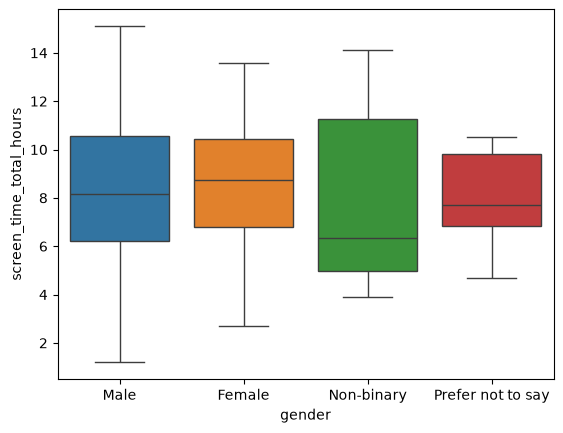

In [26]:
sns.boxplot(
    data = df,
    x = "gender",
    y = "screen_time_total_hours",
    hue = "gender"
)

In [25]:
pd.crosstab(
    df["gender"],
    df["preferred_genre"]
)

preferred_genre,Battle Royale,Casual,FPS,Horror,MMORPG,MOBA,RPG,Sandbox,Sports,Strategy
gender,,,,,,,,,,
Female,9,8,3,5,12,4,7,7,5,6
Male,15,16,16,10,22,18,14,17,10,20
Non-binary,2,3,2,1,3,1,2,4,0,0
Prefer not to say,0,2,0,1,2,0,0,1,1,1


country
USA            62
India          42
Brazil         20
Germany        18
UK             16
Russia         15
Japan          13
Canada         11
Other          11
Australia       8
Indonesia       8
Mexico          8
South Korea     7
China           7
France          4
Name: count, dtype: int64

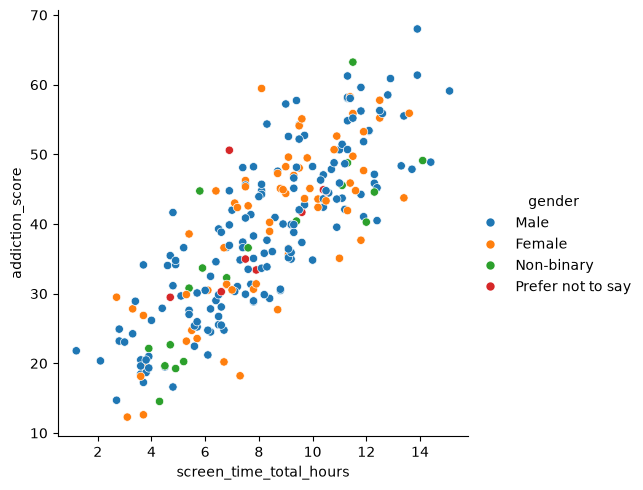

In [32]:
sns.relplot(
    data = df,
    x = "screen_time_total_hours",
    y = "addiction_score",
    hue = "gender",
)

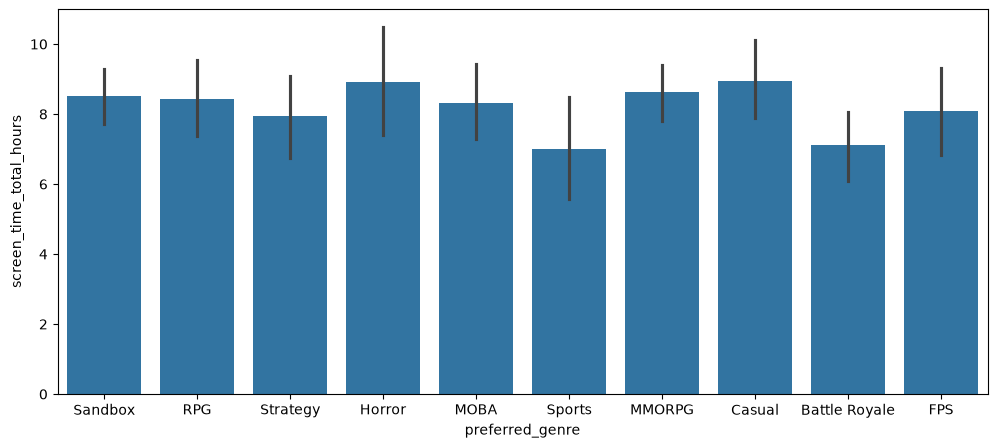

In [39]:
plt.figure(figsize = (12, 5))

sns.barplot (
    data = df,
    x = "preferred_genre",
    y = "screen_time_total_hours"
)

plt.show()